In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [46]:
class Host:
    def __init__(self, x, y, threshold = 1, infect_rate = 2, total_n_pathogens = 30): # look at the standard values
        self.threshold = threshold                      # threshold above which host becomes diseased --> establishment
        self.infect_rate = infect_rate                  # rate of infection from this host species
        self.total_n_pathogens = total_n_pathogens      # total number of pathogens that the host can have: growth limit

        self.diseased = False                           # disease status of host
        self.n_pathogens = 0                            # number of pathogen particles in the host 

        self.x = x
        self.y = y

    def initial_diseased(self, n_pathogens):
        self.diseased = True
        self.n_pathogens += n_pathogens 

    def check_diseased(self):
        if self.n_pathogens > self.threshold:
            self.diseased = True

class Grid:
    def __init__(self, n_rows, n_cols, network_type):
        assert network_type in ["lattice_hex", "lattice_square", "random"], f"network_type needs to be one of: [lattice_hex, lattice_square, random], got {network_type}"
        
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.network_type = network_type

    def get_xy_stats(self, x_vals_grid, y_vals_grid):
        xy_stats = {}
        xy_stats["x_vals_grid"] = x_vals_grid; xy_stats["y_vals_grid"] = y_vals_grid
        x_vals = np.unique(x_vals_grid); y_vals = np.unique(y_vals_grid)

        xy_stats["xmin"] = np.min(x_vals_grid); xy_stats["xmax"] = np.max(x_vals_grid)
        xy_stats["ymin"] = np.min(y_vals_grid); xy_stats["ymax"] = np.max(y_vals_grid)
        xy_stats["dx"] = x_vals[1] - x_vals[0]; xy_stats["dy"] = y_vals[1] - y_vals[0]

        return xy_stats

class HexaGrid(Grid):
    def __init__(self, n_rows, n_cols):
        super().__init__(n_rows, n_cols, "lattice_hex")
    
    def get_neighbors(self, node, xy_stats):
        x, y = node
        dx = xy_stats["dx"]; dy = xy_stats["dy"]
        xmin = xy_stats["xmin"]; xmax = xy_stats["xmax"]
        ymin = xy_stats["ymin"]; ymax = xy_stats["ymax"]

        # Get hexagonal grid neighbors (for this data)
        neighbors = [(x + dx, y + dy), (x + dx, y - dy), (x + 2*dx, y), 
                    (x - dx, y + dy), (x - dx, y - dy), (x - 2*dx, y)]
        
        # Check whether the neighbors are within the limits of the grid
        valid_neighbors = []
        for x_nbr, y_nbr in neighbors:
            if xmin <= x_nbr <= xmax and ymin <= y_nbr <= ymax:
                valid_neighbors.append((x_nbr, y_nbr))
        
        return set(valid_neighbors)
        
    def build_lattice(self):
        # assert statement for self.n_hosts
        x_vals = np.arange(0, self.n_cols, 1)
        y_vals = np.arange(0, self.n_rows, 1)

        x_vals_grid = []
        y_vals_grid = []

        self.node_dict = {}; node_idx = 0
        self.host_list = []
        for i, x in enumerate(x_vals):
            start = 0 if i % 2 == 0 else 1 # staggered columns in hexagonal grid
            for j in range(start, len(y_vals), 2):
                y = y_vals[j]
                self.host_list.append(Host(x, y))
                self.node_dict[node_idx] = (x, y)

                x_vals_grid.append(x)
                y_vals_grid.append(y)
                node_idx += 1
        
        self.coord_to_idx = {coord: idx for idx, coord in self.node_dict.items()}
        self.xy_stats = super().get_xy_stats(np.array(x_vals_grid), np.array(y_vals_grid))
        self.n_hosts = len(self.node_dict)

        neighbor_dict = {}; self.link_set = set()
        for node_ID, node in self.node_dict.items():
            node_nbrs = self.get_neighbors(node, self.xy_stats)
            nbr_IDs = [self.coord_to_idx[nbr] for nbr in node_nbrs]

            neighbor_dict[node_ID] = nbr_IDs

            for nbr_ID in nbr_IDs:
                link = tuple(sorted((node_ID, nbr_ID))) # make sure each link only gets added once
                self.link_set.add(link)

    def visualize(self, node_color = "forestgreen", link_color = "gray", show = True, lab = False):
        plt.figure(figsize = (6,6))
        for idx, node in self.node_dict.items():
            x, y = node
            if lab:
                lab = "Plant" if idx == 0 else ""
            else:
                lab = None

            plt.scatter(x, y, zorder = 2, color = node_color, s = 100, edgecolors = "white", 
                        marker = "s", label = lab)

        for link in self.link_set:
            node_ID1, node_ID2 = link
            coord1 = self.node_dict[node_ID1]; coord2 = self.node_dict[node_ID2]
            plt.plot([coord1[0], coord2[0]], [coord1[1], coord2[1]], zorder = 1, 
                     color = link_color, alpha = 0.5)
        plt.axis('off')
        if show:
            plt.show()

class DiseaseProgression:
    def __init__(self, n_hosts_infected, n_init_pathogens, grid, T_end, infection_type = "random"):
        assert infection_type in ["random"], f"infection_type needs to be in [random], got {infection_type}"
        self.infection_type = infection_type

        self.n_hosts_infected = n_hosts_infected
        self.n_init_pathogens = n_init_pathogens
        self.grid = grid
        self.T_end = T_end

    def initial_innoculation(self, seed = 3):
        np.random.seed(seed)
        if self.infection_type == "random":
            self.initial_diseased_hosts = np.random.choice(self.grid.host_list, size = self.n_hosts_infected, replace = False)

        for host in self.initial_diseased_hosts:
            host.initial_diseased(self.n_init_pathogens)

    def spread_disease(self):
        self.diseased_hosts = self.initial_diseased_hosts.copy()
        link_len = 1

        t = 0
        while t < self.T_end:
            times_until_infection = [host.infect_rate * link_len for host in self.diseased_hosts] # change this to work for after step 1 (subtract the time that has passed)
            t_next_infection = np.min(times_until_infection)
            infecting_hosts = np.array(self.diseased_hosts)[np.argmin(times_until_infection)]

            for infecting_host in infecting_hosts:
                host_coords = infecting_host.x, infecting_host.y
                nbr_coords = self.grid.get_neighbors(host_coords, self.grid.xy_stats) # these are the coordinates, not the Host() objects or indices in the list

                for nbr_coord in nbr_coords:
                    nbr_idx = self.grid.coord_to_idx(nbr_coord)
                    nbr = self.grid.host_list[nbr_idx]

                    nbr.n_pathogens += 1
                    nbr.check_diseased()

                    # check again which species are now diseased and add them to the list

            t += t_next_infection 

    def visualize_disease(self, show = True, lab = False):
        self.grid.visualize(show = False, lab = lab)
        for i, init_diseased_host in enumerate(self.initial_diseased_hosts):
            plt.scatter(init_diseased_host.x, init_diseased_host.y, color = "red", s = 180, 
                        zorder = 1, marker = "s")
        if show:
            plt.show()


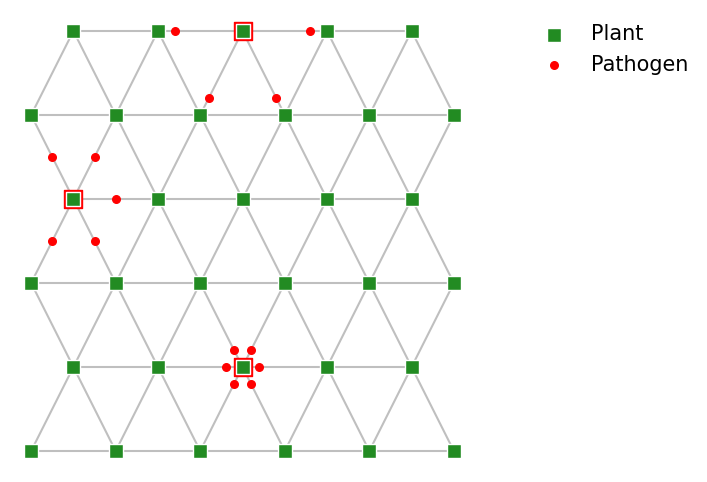

In [47]:
n_rows = 6; n_cols = n_rows * 2 - 1 # to make a square
HG = HexaGrid(n_rows, n_cols)
HG.build_lattice()

DP = DiseaseProgression(HG.n_hosts // 10, 10, HG, 100)
DP.initial_innoculation()
DP.visualize_disease(show = False, lab = True)

def cart_to_polar(x, y):
    r = np.sqrt(x ** 2 + y ** 2)
    phi = np.arccos(x / r) if y >= 0 else -np.arccos(x / r)
    return r, phi

def polar_to_cart(r, phi):
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y 

idx = 0
for diseased_host, i in zip(DP.initial_diseased_hosts, [0.5, 0.2, 0.8]):
    host_x, host_y = diseased_host.x, diseased_host.y
    nbr_coords = HG.get_neighbors((host_x, host_y), HG.xy_stats)
    for nbr in nbr_coords:
        x1, y1 = nbr[0], nbr[1]
        x2, y2 = host_x, host_y
        
        line_segment = np.array([x2 - x1, y2 - y1])
        r, phi = cart_to_polar(line_segment[0], line_segment[1])
        r_inf = r * i
        x_inf, y_inf = polar_to_cart(r_inf, phi)

        plt.scatter(x_inf + x1, y_inf+ y1, color = "red", s = 30, zorder = 4, 
                    label = "Pathogen" if idx == 0 else "")
        idx += 1
plt.legend(fontsize = 15, bbox_to_anchor = [1.5, 1.01], loc = "upper right", frameon = False)
plt.show()